In [1]:
# notebook to plot some distributions, etc. for the multiTF analysis

In [2]:
# import packages
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.patches as patches
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [3]:
# open multiEmVar TSVs
openTargets_multiTF = pd.read_csv('multiTF_cluster/Phenocopy_openTargets_GWAS_multiTF_emVars_highPIP_gnomAD_v4_annotated_4bp_pad.tsv', sep = '\t')
GTEx_multiTF = pd.read_csv('multiTF_cluster/Phenocopy_GTEx_MultiTF_emVars_HighPIP_gnomAD_v4_annotated_4bp_pad.tsv', sep = '\t')

In [4]:
# add column with lead variant skew to more easily calculate delta skew
def addLeadVarSkew (multiTF_DF, leadVarCol):
    cellDFs2cat = []
    # iterate through each cell type
    for cell in ['k562', 'hepg2', 'sknsh']:
        # filter for that cell type to keep the skews straight
        cellDF = multiTF_DF[multiTF_DF['cell_type'] == cell].copy()
        # filter for lead variants
        cellLeadVar = cellDF[cellDF['is_leadVariant'] == 1].copy()
        # make a dictionary of lead variants and skews
        cellLeadVarDict = dict(zip(cellLeadVar[leadVarCol], cellLeadVar['skew_pred']))
        # add column to DF
        cellDF.loc[:,'leadVar_skew'] = [cellLeadVarDict.get(i) for i in cellDF[leadVarCol]]
        # calculate delta skew
        cellDF.loc[:, 'delta_lead'] = cellDF['leadVar_skew'] - cellDF['skew_pred']
        cellDFs2cat.append(cellDF)
    # concatenate all cell DFs and return
    return pd.concat(cellDFs2cat)

In [5]:
# get the delta lead for each variant
openTargets_multiTF = addLeadVarSkew(openTargets_multiTF, 'leadVariant')
GTEx_multiTF = addLeadVarSkew(GTEx_multiTF, 'leadVar')

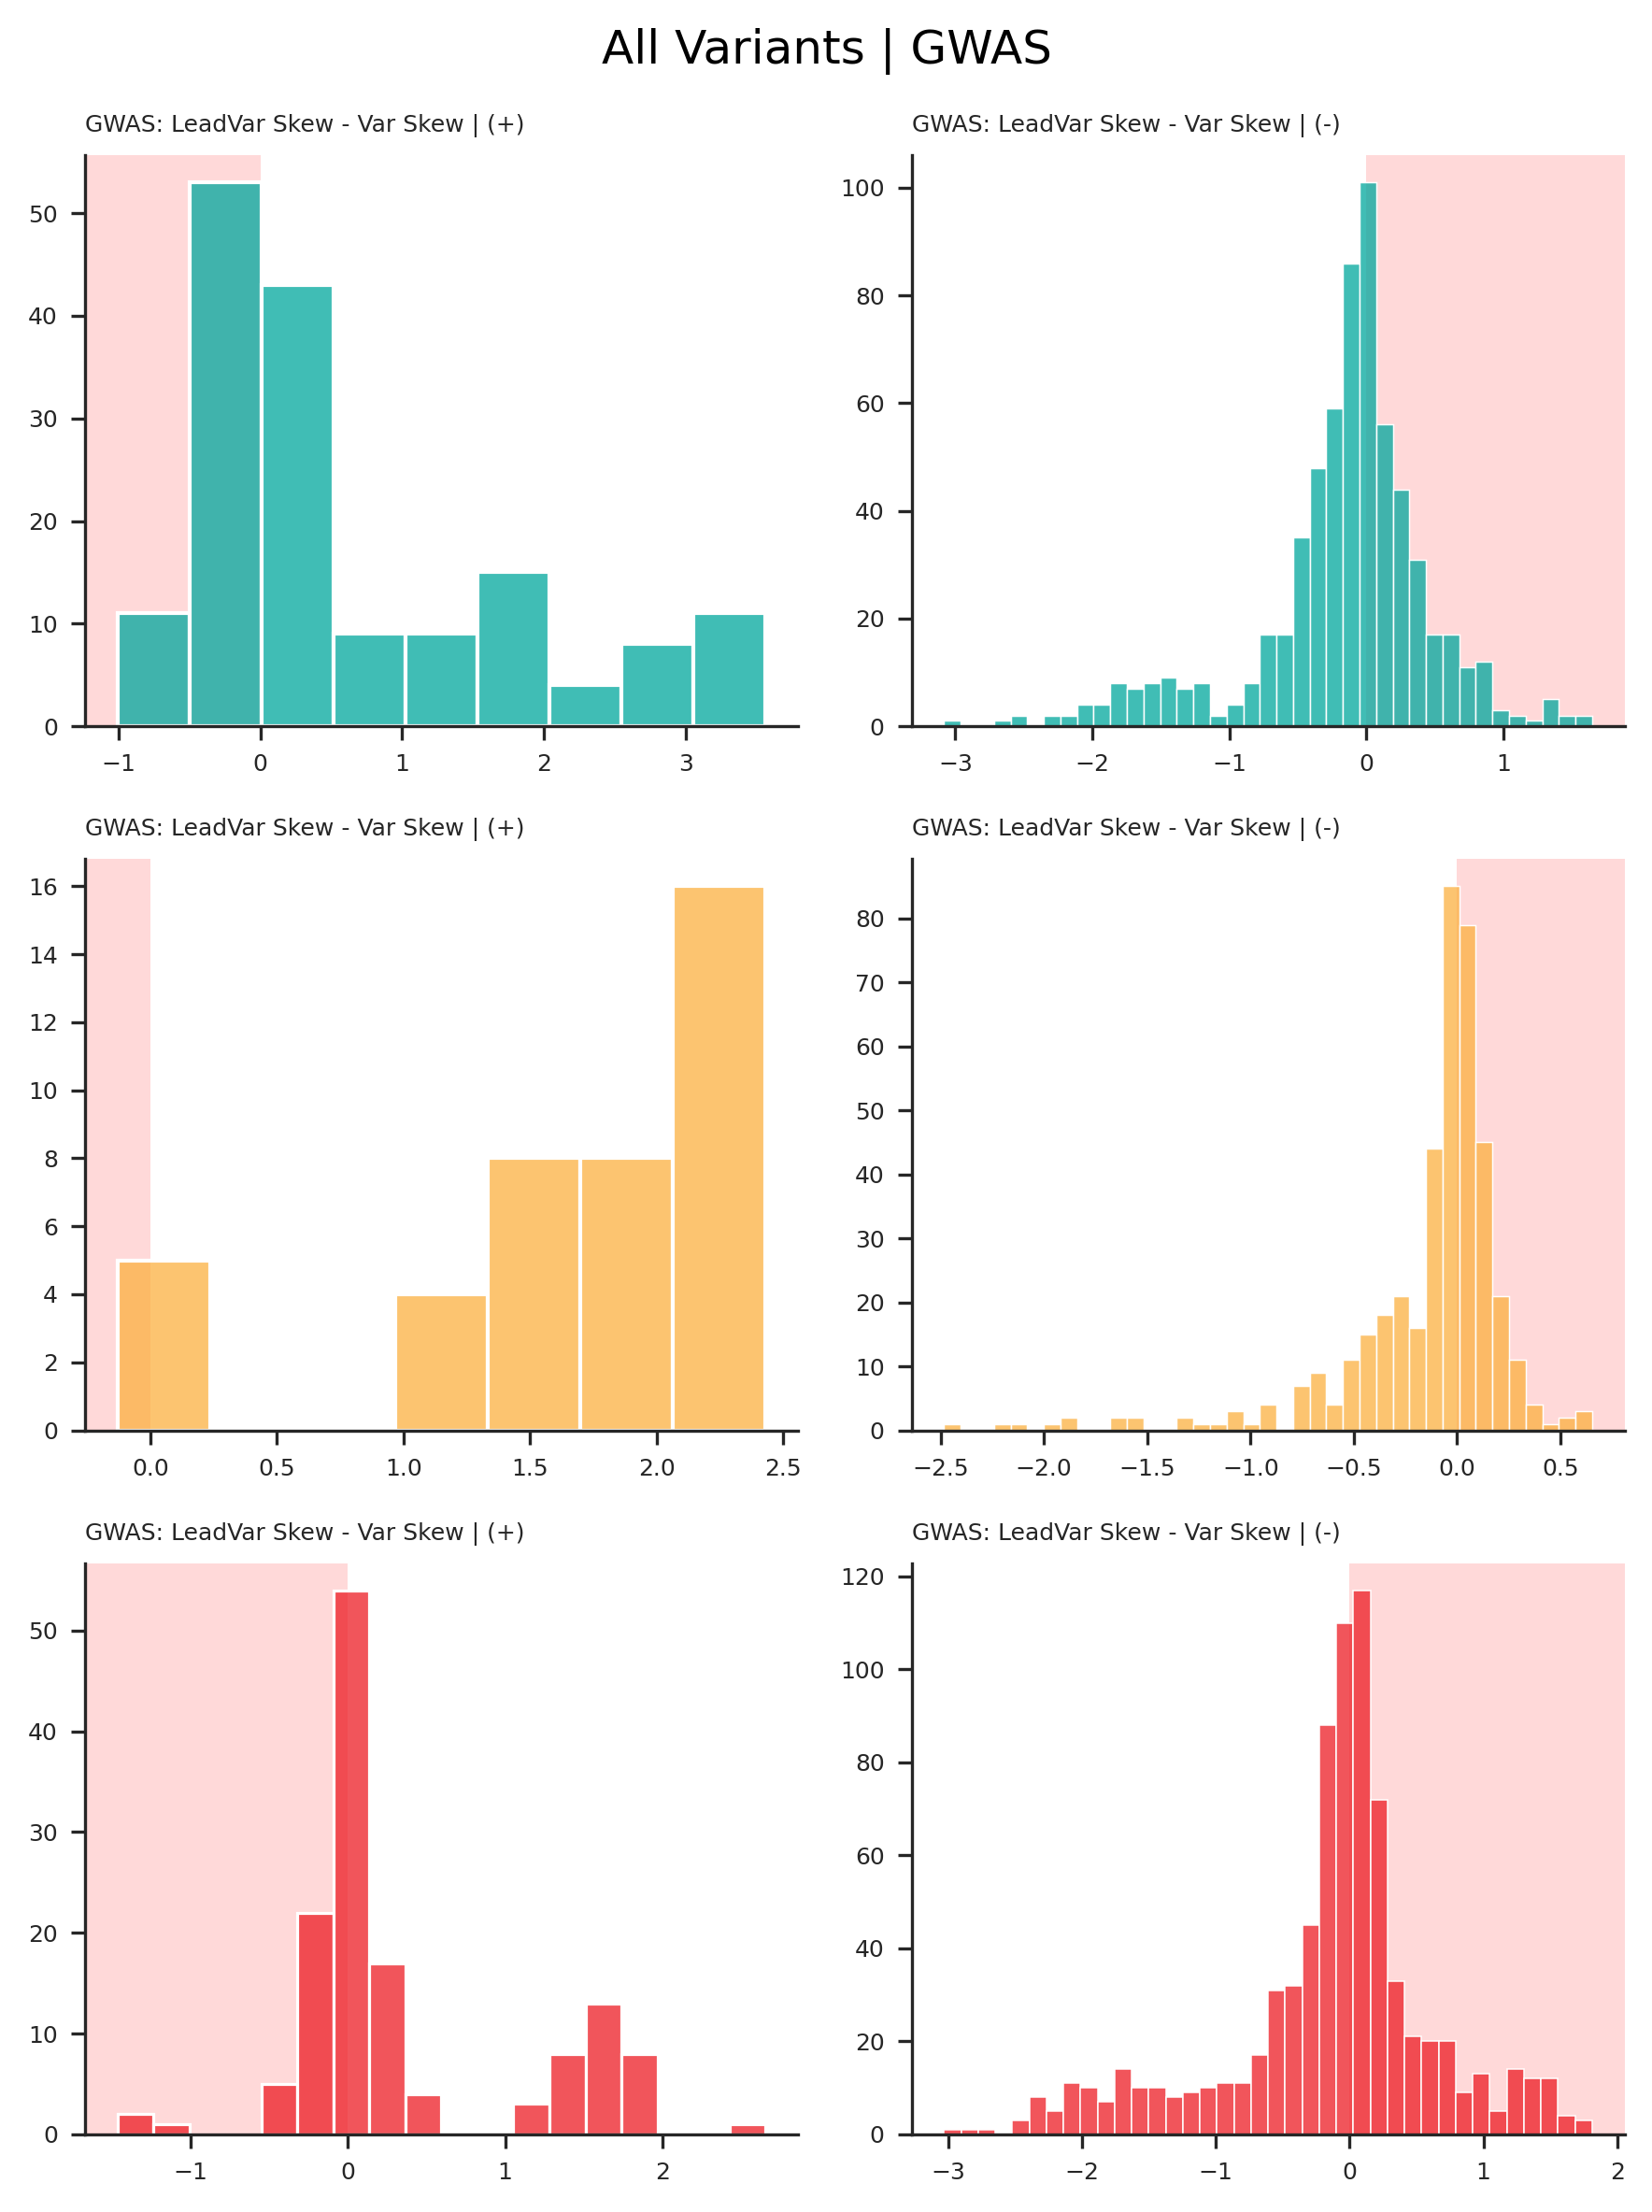

In [6]:
# split data into positive and negative skew and plot for each cell type
f = plt.figure(figsize = (6,8), dpi = 300)
gs = f.add_gridspec(3,2)
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['axes.labelsize'] = 8
# plot k562 positive lead skew #
with sns.axes_style('ticks'):
    kPosSkew = openTargets_multiTF[(openTargets_multiTF['leadVar_skew'] > 0) & (openTargets_multiTF['cell_type'] == 'k562')].filter(['delta_lead']).drop_duplicates()
    ax01 = f.add_subplot(gs[0,0])
    sns.histplot(
        data=kPosSkew,
        x='delta_lead',
        color='#00A79D'
    )
    # add shaded region for x < 0
    ymin, ymax = ax01.get_ylim()
    xmin, xmax = ax01.get_xlim()
    rect = patches.Rectangle(
        (xmin, ymin),              # bottom-left corner
        abs(xmin),                  # width (from xmin to 0)
        ymax - ymin,                # height (full y range)
        facecolor='red',
        alpha=0.15,
        edgecolor='none',
        zorder=0                    # behind the bars
    )
    ax01.add_patch(rect)
    ax01.tick_params(axis='both', labelsize=6)
    plt.title('GWAS: LeadVar Skew - Var Skew | (+)', loc = 'left', fontsize=6)
    plt.xlabel('')
    plt.ylabel('')
# plot k562 negative lead skew #
with sns.axes_style('ticks'):
    kNegSkew = openTargets_multiTF[(openTargets_multiTF['leadVar_skew'] <= 0) & (openTargets_multiTF['cell_type'] == 'k562')].filter(['delta_lead']).drop_duplicates()
    ax02 = f.add_subplot(gs[0,1])
    sns.histplot(
        data=kNegSkew,
        x='delta_lead',
        color='#00A79D'
    )
    # add shaded region for x < 0
    ymin, ymax = ax02.get_ylim()
    xmin, xmax = ax02.get_xlim()
    rect = patches.Rectangle(
        (0, ymin),              # bottom-left corner
        abs(xmax),                  # width (from xmin to 0)
        ymax - ymin,                # height (full y range)
        facecolor='red',
        alpha=0.15,
        edgecolor='none',
        zorder=0                    # behind the bars
    )
    ax02.add_patch(rect)
    ax02.tick_params(axis='both', labelsize=6)
    plt.title('GWAS: LeadVar Skew - Var Skew | (-)', loc = 'left', fontsize=6)
    plt.xlabel('')
    plt.ylabel('')
# plot hepg2 positive lead skew #
with sns.axes_style('ticks'):
    hPosSkew = openTargets_multiTF[(openTargets_multiTF['leadVar_skew'] > 0) & (openTargets_multiTF['cell_type'] == 'hepg2')].filter(['delta_lead']).drop_duplicates()
    ax03 = f.add_subplot(gs[1,0])
    sns.histplot(
        data=hPosSkew,
        x='delta_lead',
        color='#FBB040'
    )
    # add shaded region for x < 0
    ymin, ymax = ax03.get_ylim()
    xmin, xmax = ax03.get_xlim()
    rect = patches.Rectangle(
        (xmin, ymin),              # bottom-left corner
        abs(xmin),                  # width (from xmin to 0)
        ymax - ymin,                # height (full y range)
        facecolor='red',
        alpha=0.15,
        edgecolor='none',
        zorder=0                    # behind the bars
    )
    ax03.add_patch(rect)
    ax03.tick_params(axis='both', labelsize=6)
    plt.title('GWAS: LeadVar Skew - Var Skew | (+)', loc = 'left', fontsize=6)
    plt.xlabel('')
    plt.ylabel('')
# plot hepg2 negative lead skew #
with sns.axes_style('ticks'):
    hNegSkew = openTargets_multiTF[(openTargets_multiTF['leadVar_skew'] <= 0) & (openTargets_multiTF['cell_type'] == 'hepg2')].filter(['delta_lead']).drop_duplicates()
    ax04 = f.add_subplot(gs[1,1])
    sns.histplot(
        data=hNegSkew,
        x='delta_lead',
        color='#FBB040'
    )
    # add shaded region for x < 0
    ymin, ymax = ax04.get_ylim()
    xmin, xmax = ax04.get_xlim()
    rect = patches.Rectangle(
        (0, ymin),              # bottom-left corner
        abs(xmax),                  # width (from xmin to 0)
        ymax - ymin,                # height (full y range)
        facecolor='red',
        alpha=0.15,
        edgecolor='none',
        zorder=0                    # behind the bars
    )
    ax04.add_patch(rect)
    ax04.tick_params(axis='both', labelsize=6)
    plt.title('GWAS: LeadVar Skew - Var Skew | (-)', loc = 'left', fontsize=6)
    plt.xlabel('')
    plt.ylabel('')
# plot sknsh positive lead skew #
with sns.axes_style('ticks'):
    sPosSkew = openTargets_multiTF[(openTargets_multiTF['leadVar_skew'] > 0) & (openTargets_multiTF['cell_type'] == 'sknsh')].filter(['delta_lead']).drop_duplicates()
    ax05 = f.add_subplot(gs[2,0])
    sns.histplot(
        data=sPosSkew,
        x='delta_lead',
        color='#ED1C24'
    )
    # add shaded region for x < 0
    ymin, ymax = ax05.get_ylim()
    xmin, xmax = ax05.get_xlim()
    rect = patches.Rectangle(
        (xmin, ymin),              # bottom-left corner
        abs(xmin),                  # width (from xmin to 0)
        ymax - ymin,                # height (full y range)
        facecolor='red',
        alpha=0.15,
        edgecolor='none',
        zorder=0                    # behind the bars
    )
    ax05.add_patch(rect)
    ax05.tick_params(axis='both', labelsize=6)
    plt.title('GWAS: LeadVar Skew - Var Skew | (+)', loc = 'left', fontsize=6)
    plt.xlabel('')
    plt.ylabel('')
# plot sknsh negative lead skew #
with sns.axes_style('ticks'):
    sNegSkew = openTargets_multiTF[(openTargets_multiTF['leadVar_skew'] <= 0) & (openTargets_multiTF['cell_type'] == 'sknsh')].filter(['delta_lead']).drop_duplicates()
    ax06 = f.add_subplot(gs[2,1])
    sns.histplot(
        data=sNegSkew,
        x='delta_lead',
        color='#ED1C24'
    )
    # add shaded region for x < 0
    ymin, ymax = ax06.get_ylim()
    xmin, xmax = ax06.get_xlim()
    rect = patches.Rectangle(
        (0, ymin),              # bottom-left corner
        abs(xmax),                  # width (from xmin to 0)
        ymax - ymin,                # height (full y range)
        facecolor='red',
        alpha=0.15,
        edgecolor='none',
        zorder=0                    # behind the bars
    )
    ax06.add_patch(rect)
    ax06.tick_params(axis='both', labelsize=6)
    plt.title('GWAS: LeadVar Skew - Var Skew | (-)', loc = 'left', fontsize=6)
    plt.xlabel('')
    plt.ylabel('')
plt.suptitle('All Variants | GWAS')
sns.despine()
plt.tight_layout()

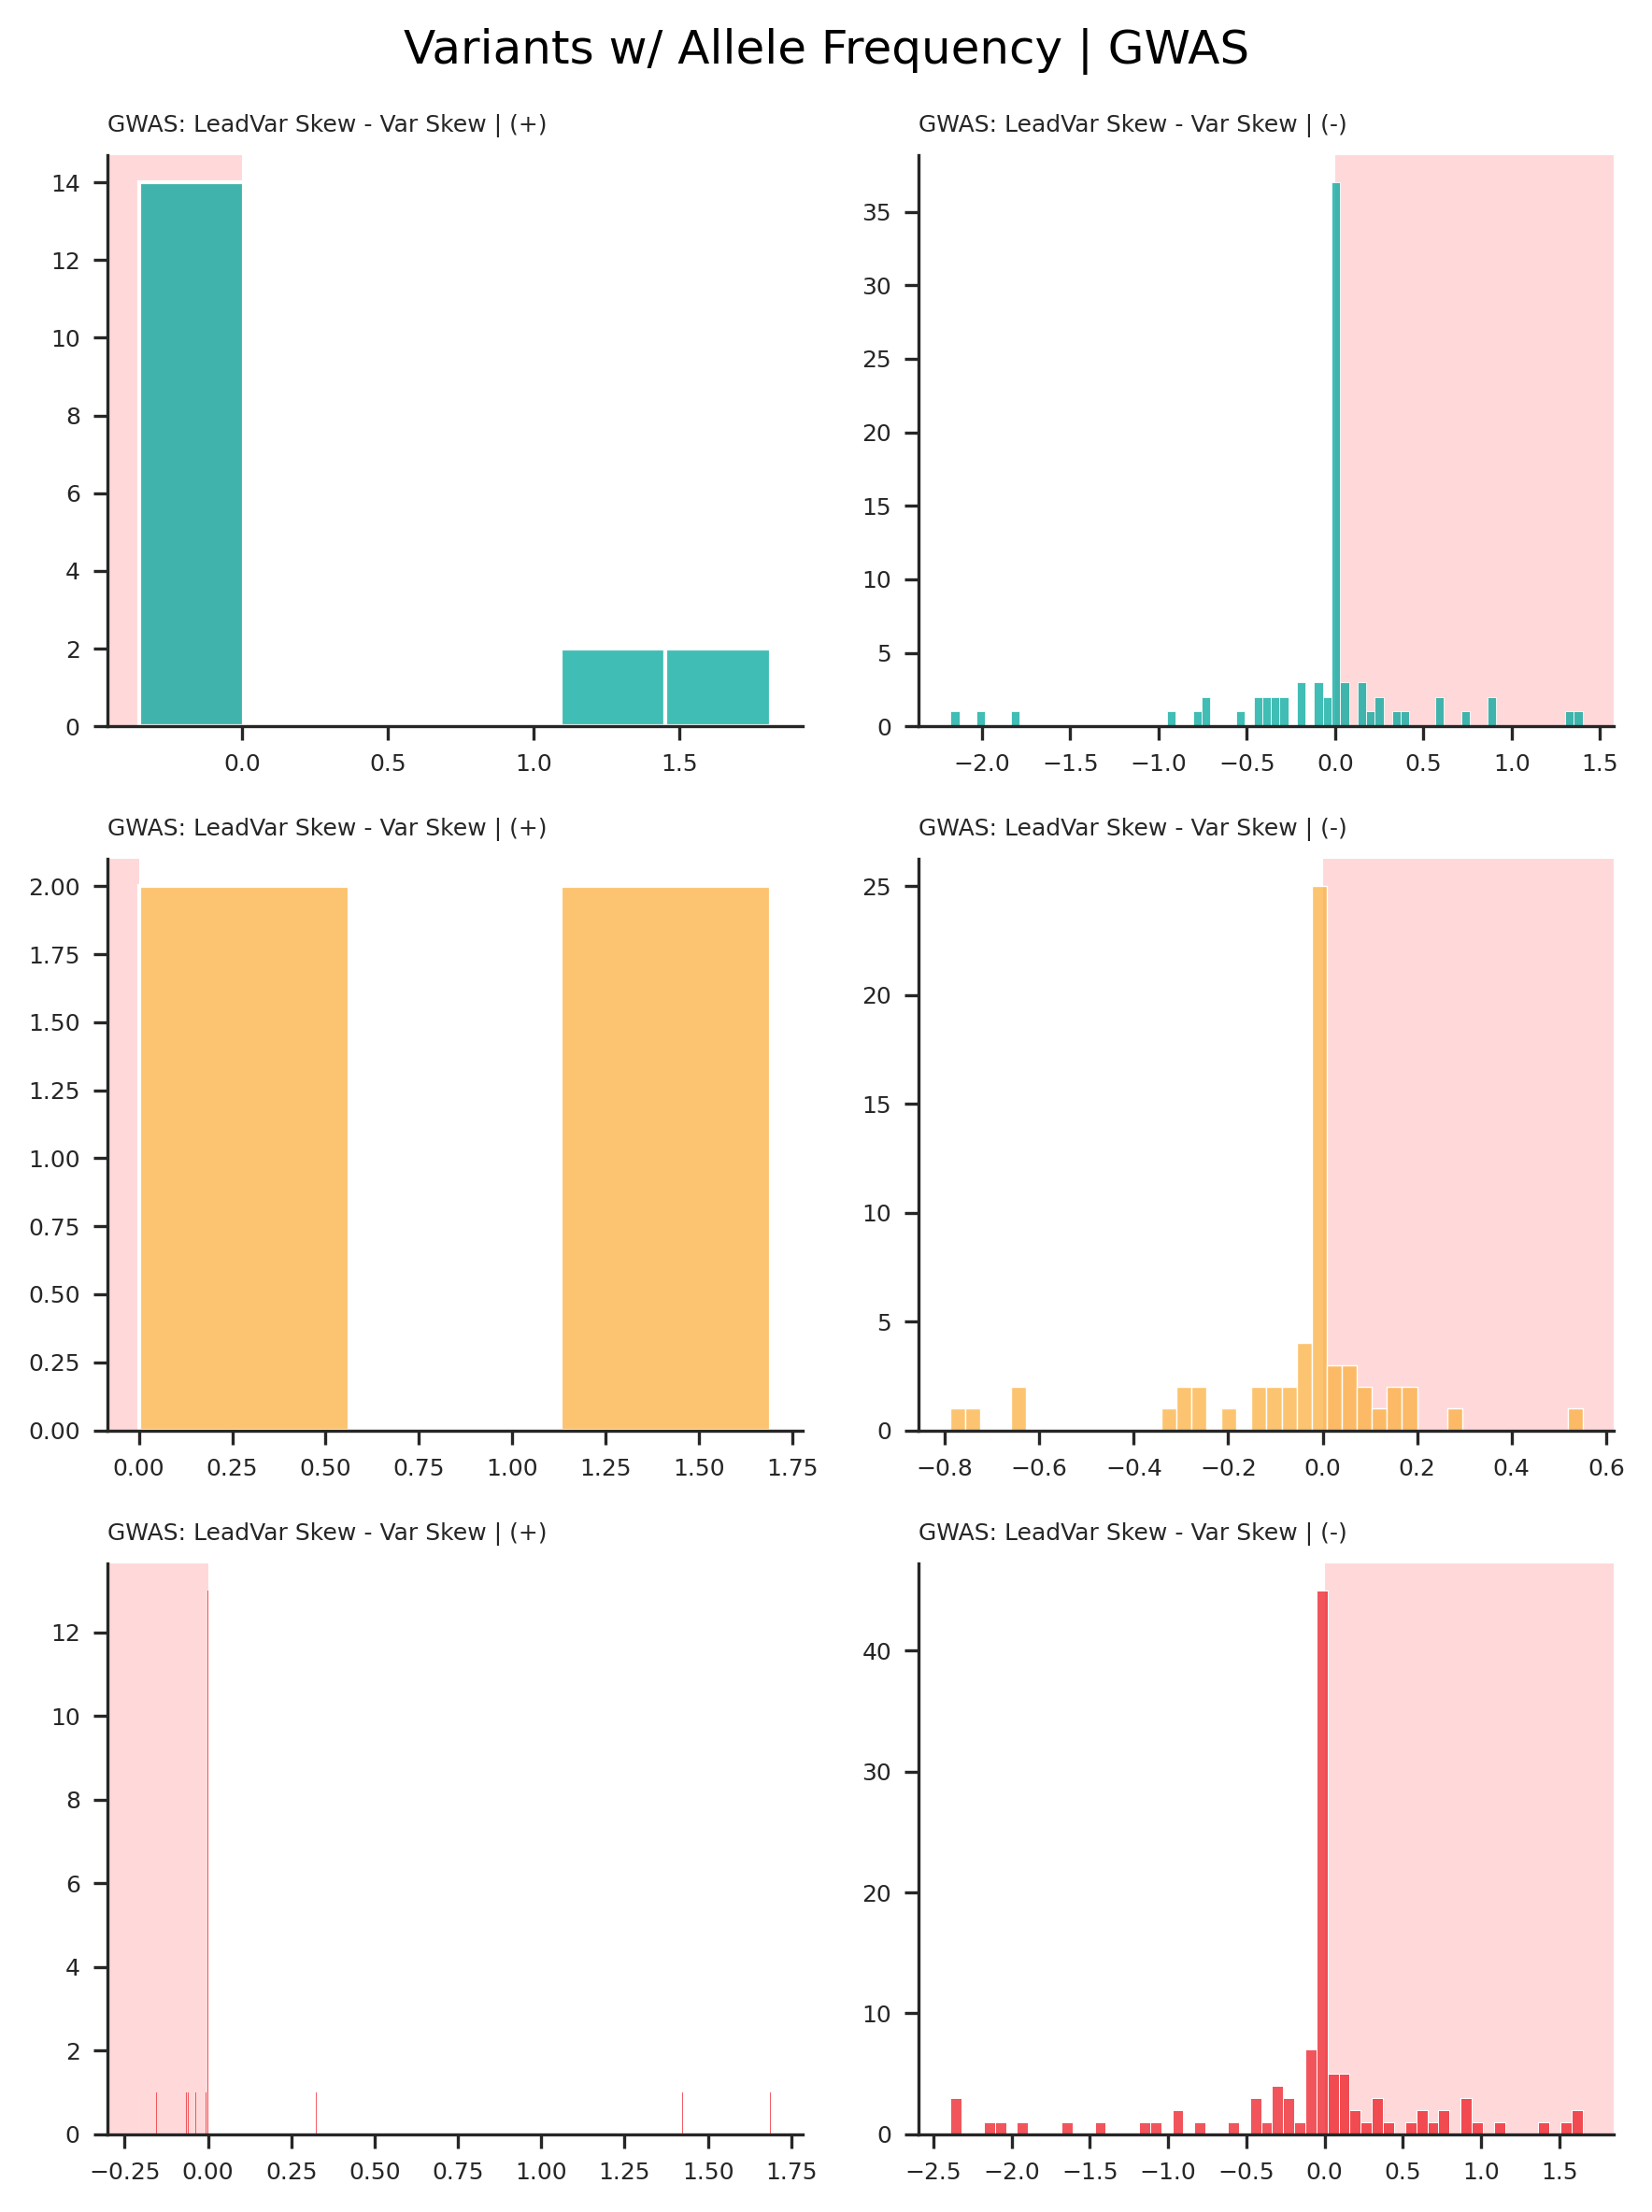

In [7]:
# split data into positive and negative skew and plot for each cell type
f = plt.figure(figsize = (6,8), dpi = 300)
gs = f.add_gridspec(3,2)
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['axes.labelsize'] = 8
# plot k562 positive lead skew #
with sns.axes_style('ticks'):
    kPosSkew = openTargets_multiTF[(openTargets_multiTF['leadVar_skew'] > 0) & (openTargets_multiTF['cell_type'] == 'k562')].filter(['delta_lead', 'af']).drop_duplicates().dropna()
    ax01 = f.add_subplot(gs[0,0])
    sns.histplot(
        data=kPosSkew,
        x='delta_lead',
        color='#00A79D'
    )
    # add shaded region for x < 0
    ymin, ymax = ax01.get_ylim()
    xmin, xmax = ax01.get_xlim()
    rect = patches.Rectangle(
        (xmin, ymin),              # bottom-left corner
        abs(xmin),                  # width (from xmin to 0)
        ymax - ymin,                # height (full y range)
        facecolor='red',
        alpha=0.15,
        edgecolor='none',
        zorder=0                    # behind the bars
    )
    ax01.add_patch(rect)
    ax01.tick_params(axis='both', labelsize=6)
    plt.title('GWAS: LeadVar Skew - Var Skew | (+)', loc = 'left', fontsize=6)
    plt.xlabel('')
    plt.ylabel('')
# plot k562 negative lead skew #
with sns.axes_style('ticks'):
    kNegSkew = openTargets_multiTF[(openTargets_multiTF['leadVar_skew'] <= 0) & (openTargets_multiTF['cell_type'] == 'k562')].filter(['delta_lead', 'af']).drop_duplicates().dropna()
    ax02 = f.add_subplot(gs[0,1])
    sns.histplot(
        data=kNegSkew,
        x='delta_lead',
        color='#00A79D'
    )
    # add shaded region for x < 0
    ymin, ymax = ax02.get_ylim()
    xmin, xmax = ax02.get_xlim()
    rect = patches.Rectangle(
        (0, ymin),              # bottom-left corner
        abs(xmax),                  # width (from xmin to 0)
        ymax - ymin,                # height (full y range)
        facecolor='red',
        alpha=0.15,
        edgecolor='none',
        zorder=0                    # behind the bars
    )
    ax02.add_patch(rect)
    ax02.tick_params(axis='both', labelsize=6)
    plt.title('GWAS: LeadVar Skew - Var Skew | (-)', loc = 'left', fontsize=6)
    plt.xlabel('')
    plt.ylabel('')
# plot hepg2 positive lead skew #
with sns.axes_style('ticks'):
    hPosSkew = openTargets_multiTF[(openTargets_multiTF['leadVar_skew'] > 0) & (openTargets_multiTF['cell_type'] == 'hepg2')].filter(['delta_lead', 'af']).drop_duplicates().dropna()
    ax03 = f.add_subplot(gs[1,0])
    sns.histplot(
        data=hPosSkew,
        x='delta_lead',
        color='#FBB040'
    )
    # add shaded region for x < 0
    ymin, ymax = ax03.get_ylim()
    xmin, xmax = ax03.get_xlim()
    rect = patches.Rectangle(
        (xmin, ymin),              # bottom-left corner
        abs(xmin),                  # width (from xmin to 0)
        ymax - ymin,                # height (full y range)
        facecolor='red',
        alpha=0.15,
        edgecolor='none',
        zorder=0                    # behind the bars
    )
    ax03.add_patch(rect)
    ax03.tick_params(axis='both', labelsize=6)
    plt.title('GWAS: LeadVar Skew - Var Skew | (+)', loc = 'left', fontsize=6)
    plt.xlabel('')
    plt.ylabel('')
# plot hepg2 negative lead skew #
with sns.axes_style('ticks'):
    hNegSkew = openTargets_multiTF[(openTargets_multiTF['leadVar_skew'] <= 0) & (openTargets_multiTF['cell_type'] == 'hepg2')].filter(['delta_lead', 'af']).drop_duplicates().dropna()
    ax04 = f.add_subplot(gs[1,1])
    sns.histplot(
        data=hNegSkew,
        x='delta_lead',
        color='#FBB040'
    )
    # add shaded region for x < 0
    ymin, ymax = ax04.get_ylim()
    xmin, xmax = ax04.get_xlim()
    rect = patches.Rectangle(
        (0, ymin),              # bottom-left corner
        abs(xmax),                  # width (from xmin to 0)
        ymax - ymin,                # height (full y range)
        facecolor='red',
        alpha=0.15,
        edgecolor='none',
        zorder=0                    # behind the bars
    )
    ax04.add_patch(rect)
    ax04.tick_params(axis='both', labelsize=6)
    plt.title('GWAS: LeadVar Skew - Var Skew | (-)', loc = 'left', fontsize=6)
    plt.xlabel('')
    plt.ylabel('')
# plot sknsh positive lead skew #
with sns.axes_style('ticks'):
    sPosSkew = openTargets_multiTF[(openTargets_multiTF['leadVar_skew'] > 0) & (openTargets_multiTF['cell_type'] == 'sknsh')].filter(['delta_lead', 'af']).drop_duplicates().dropna()

    ax05 = f.add_subplot(gs[2,0])
    sns.histplot(
        data=sPosSkew,
        x='delta_lead',
        color='#ED1C24'
    )
    # add shaded region for x < 0
    ymin, ymax = ax05.get_ylim()
    xmin, xmax = ax05.get_xlim()
    rect = patches.Rectangle(
        (xmin, ymin),              # bottom-left corner
        abs(xmin),                  # width (from xmin to 0)
        ymax - ymin,                # height (full y range)
        facecolor='red',
        alpha=0.15,
        edgecolor='none',
        zorder=0                    # behind the bars
    )
    ax05.add_patch(rect)
    ax05.tick_params(axis='both', labelsize=6)
    plt.title('GWAS: LeadVar Skew - Var Skew | (+)', loc = 'left', fontsize=6)
    plt.xlabel('')
    plt.ylabel('')
# plot sknsh negative lead skew #
with sns.axes_style('ticks'):
    sNegSkew = openTargets_multiTF[(openTargets_multiTF['leadVar_skew'] <= 0) & (openTargets_multiTF['cell_type'] == 'sknsh')].filter(['delta_lead', 'af']).drop_duplicates().dropna()
    ax06 = f.add_subplot(gs[2,1])
    sns.histplot(
        data=sNegSkew,
        x='delta_lead',
        color='#ED1C24'
    )
    # add shaded region for x < 0
    ymin, ymax = ax06.get_ylim()
    xmin, xmax = ax06.get_xlim()
    rect = patches.Rectangle(
        (0, ymin),              # bottom-left corner
        abs(xmax),                  # width (from xmin to 0)
        ymax - ymin,                # height (full y range)
        facecolor='red',
        alpha=0.15,
        edgecolor='none',
        zorder=0                    # behind the bars
    )
    ax06.add_patch(rect)
    ax06.tick_params(axis='both', labelsize=6)
    plt.title('GWAS: LeadVar Skew - Var Skew | (-)', loc = 'left', fontsize=6)
    plt.xlabel('')
    plt.ylabel('')
plt.suptitle('Variants w/ Allele Frequency | GWAS')
sns.despine()
plt.tight_layout()

In [8]:
# get the highest confidence GTEx Variants (ie greatest delta lead)
# focus on negatively skewed variants as those are the only ones showing a large delta
# k562
openTargets_multiTF[(openTargets_multiTF['leadVar_skew'] <= 0) & # get negative variants
                    (openTargets_multiTF['cell_type'] == 'k562') & # get cell type
                    (openTargets_multiTF['delta_lead'] > 0.5)].dropna() # get those with a 'large' delta_lead and have an allele frequency

,variant_id,chrom,pos,ref,alt,cell_type,skew_pred,enhancer_ids,is_multiTF,openTargets_id,tf_family,tf_contrib,tf_instance,leadVariant,is_leadVariant,af,AF_afr,AF_ami,AF_amr,AF_asj,AF_eas,AF_fin,AF_mid,AF_nfe,AF_remaining,AF_sas,studyId,traitFromSource,posteriorProbability,is95CredibleSet,finemappingMethod,abs_skew,lead_abs_skew,max_abs_skew,skew_ratio,leadVar_skew,delta_lead
977,chr1:6917292:G:A,chr1,6917292,G,A,k562,-1.151762,EH38E1314911,True,1_6917292_G_A,Ebox/CACCTG,-3.865017,1,1_6917291_C_T,0,0.000020,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0,0.000015,0.000000,0.000414,GCST90480644,Personal history of allergy to medicinal agent...,1.000000,True,PICS,1.151762,0.536360,1.286450,2.398482,-0.536360,0.615402
4057,chr11:6316295:T:C,chr11,6316295,T,C,k562,-1.919974,EH38E2942188,True,11_6316295_T_C,GATA,7.501331,2,11_6316291_C_A,0,0.000020,0.000000,0.0,0.000196,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.000000,GCST90612823,Platelet endothelial cell adhesion molecule pr...,0.999998,True,SuSiE-inf,1.919974,0.518901,1.919974,3.700081,-0.518901,1.401074
4060,chr11:6316296:C:G,chr11,6316296,C,G,k562,-1.428349,EH38E2942188,True,11_6316296_C_G,GATA,7.501331,2,11_6316291_C_A,0,0.000007,0.000000,0.0,0.000000,0.0,0.000193,0.0,0.0,0.000000,0.000000,0.000000,GCST90612823,Platelet endothelial cell adhesion molecule pr...,0.999998,True,SuSiE-inf,1.428349,0.518901,1.919974,3.700081,-0.518901,0.909448
4173,chr2:1496359:G:A,chr2,1496359,G,A,k562,-1.839837,EH38E3320001,True,2_1496359_G_A,KLF/SP/2,9.405340,2,2_1496361_G_A,0,0.000040,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0,0.000088,0.000000,0.000000,GCST90479837,"Benign neoplasm of lip, oral cavity, and phary...",1.000000,True,PICS,1.839837,1.082117,1.839837,1.700220,-1.082117,0.757720
24893,chr6:160012539:C:T,chr6,160012539,C,T,k562,-1.312027,EH38E4423219,True,6_160012539_C_T,KLF/SP/2,3.842722,1,6_160012541_C_T,0,0.000534,0.001863,0.0,0.000197,0.0,0.000000,0.0,0.0,0.000000,0.000476,0.000000,GCST90480148,Other hypertrophic cardiomyopathy (PheCode 425...,1.000000,True,PICS,1.312027,0.735476,1.344699,1.828337,-0.735476,0.576551
24907,chr7:50197733:T:C,chr7,50197733,T,C,k562,-1.970473,EH38E4436489,True,7_50197733_T_C,AP1/1,15.229640,3,7_50197743_C_T,0,0.000007,0.000024,0.0,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.000000,GCST90609706,Serine/threonine-protein phosphatase 2A 56 kDa...,1.000000,True,PICS,1.970473,1.091123,2.739042,2.510296,-1.091123,0.879350
24922,chr7:50197738:C:T,chr7,50197738,C,T,k562,-2.397670,EH38E4436489,True,7_50197738_C_T,AP1/1,15.229640,3,7_50197743_C_T,0,0.000007,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.000207,GCST90609706,Serine/threonine-protein phosphatase 2A 56 kDa...,1.000000,True,PICS,2.397670,1.091123,2.739042,2.510296,-1.091123,1.306547


In [6]:
# get the medium confidence GTEx Variants (ie greatest delta lead)
# focus on negatively skewed variants as those are the only ones showing a large delta
# k562
openTargets_multiTF[(openTargets_multiTF['leadVar_skew'] <= 0) & # get negative variants
                    (openTargets_multiTF['cell_type'] == 'k562') & # get cell type
                    (openTargets_multiTF['delta_lead'] < 0.5) &
                    (openTargets_multiTF['delta_lead'] > 0.2)].dropna() # get those with a 'large' delta_lead and have an allele frequency

,variant_id,chrom,pos,ref,alt,cell_type,skew_pred,enhancer_ids,is_multiTF,openTargets_id,tf_family,tf_contrib,tf_instance,leadVariant,is_leadVariant,af,studyId,traitFromSource,posteriorProbability,is95CredibleSet,finemappingMethod,abs_skew,lead_abs_skew,max_abs_skew,skew_ratio,leadVar_skew,delta_lead
1006,chr18:48073276:C:T,chr18,48073276,C,T,k562,-0.941464,EH38E1914587,True,18_48073276_C_T,Ebox/CACCTG,3.127797,1,18_48073278_C_G,0,0.000007,GCST90691843,Heel bone mineral density (BMD) (UKB data fiel...,0.985829,True,SuSiE-inf,0.941464,0.705753,1.189164,1.684958,-0.705753,0.235711
1007,chr18:48073276:C:T,chr18,48073276,C,T,k562,-0.941464,EH38E1914587,True,18_48073276_C_T,Ebox/CACCTG,3.127797,1,18_48073278_C_G,0,0.000007,GCST90014022,Bone mineral density,0.999968,True,SuSiE-inf,0.941464,0.705753,1.189164,1.684958,-0.705753,0.235711
1008,chr18:48073276:C:T,chr18,48073276,C,T,k562,-0.941464,EH38E1914587,True,18_48073276_C_T,Ebox/CACCTG,3.127797,1,18_48073278_C_G,0,0.000007,GCST90692713,Standing height (UKB data field 50),0.999972,True,SuSiE-inf,0.941464,0.705753,1.189164,1.684958,-0.705753,0.235711
1009,chr18:48073276:C:T,chr18,48073276,C,T,k562,-0.941464,EH38E1914587,True,18_48073276_C_T,Ebox/CACCTG,3.127797,1,18_48073278_C_G,0,0.000007,GCST90691864,Standing height (UKB data field 50),0.999992,True,SuSiE-inf,0.941464,0.705753,1.189164,1.684958,-0.705753,0.235711
1010,chr18:48073276:C:T,chr18,48073276,C,T,k562,-0.941464,EH38E1914587,True,18_48073276_C_T,Ebox/CACCTG,3.127797,1,18_48073278_C_G,0,0.000007,GCST90692938,Heel bone mineral density (BMD) (UKB data fiel...,0.992282,True,SuSiE-inf,0.941464,0.705753,1.189164,1.684958,-0.705753,0.235711
1011,chr18:48073276:C:T,chr18,48073276,C,T,k562,-0.941464,EH38E1914587,True,18_48073276_C_T,Ebox/CACCTG,3.127797,1,18_48073278_C_G,0,0.000007,GCST90435412,Height,1.000000,True,PICS,0.941464,0.705753,1.189164,1.684958,-0.705753,0.235711
1156,chr2:46340137:G:C,chr2,46340137,G,C,k562,-1.173138,EH38E1994844,True,2_46340137_G_C,Ebox/CACGTG/1,2.634738,2,2_46340137_G_T,0,0.000145,GCST90691759,Birth weight (UKB data field 20022),0.997100,True,SuSiE-inf,1.173138,0.827778,1.173138,1.417214,-0.827778,0.345360
1157,chr2:46340137:G:C,chr2,46340137,G,C,k562,-1.173138,EH38E1994844,True,2_46340137_G_C,Ebox/CACGTG/1,2.634738,2,2_46340137_G_T,0,0.000145,GCST90275189,"Placental weight (fetal genotype, adjusted for...",0.963124,True,SuSiE-inf,1.173138,0.827778,1.173138,1.417214,-0.827778,0.345360
1158,chr2:46340137:G:C,chr2,46340137,G,C,k562,-1.173138,EH38E1994844,True,2_46340137_G_C,Ebox/CACGTG/1,2.634738,2,2_46340137_G_T,0,0.000145,GCST90692736,Birth weight (UKB data field 20022),0.998499,True,SuSiE-inf,1.173138,0.827778,1.173138,1.417214,-0.827778,0.345360
1159,chr2:46340137:G:C,chr2,46340137,G,C,k562,-1.173138,EH38E1994844,True,2_46340137_G_C,Ebox/CACGTG/1,2.634738,2,2_46340137_G_T,0,0.000145,GCST90275197,"Placental weight (fetal genotype, adjusted for...",0.989531,True,SuSiE-inf,1.173138,0.827778,1.173138,1.417214,-0.827778,0.345360


In [9]:
# get the highest confidence GTEx Variants (ie greatest delta lead)
# focus on negatively skewed variants as those are the only ones showing a large delta
# hepg2
openTargets_multiTF[(openTargets_multiTF['leadVar_skew'] <= 0) & # get negative variants
                    (openTargets_multiTF['cell_type'] == 'hepg2') & # get cell type
                    (openTargets_multiTF['delta_lead'] > 0.5)].dropna() # get those with a 'large' delta_lead and have an allele frequency

,variant_id,chrom,pos,ref,alt,cell_type,skew_pred,enhancer_ids,is_multiTF,openTargets_id,tf_family,tf_contrib,tf_instance,leadVariant,is_leadVariant,af,studyId,traitFromSource,posteriorProbability,is95CredibleSet,finemappingMethod,abs_skew,lead_abs_skew,max_abs_skew,skew_ratio,leadVar_skew,delta_lead
225,chr15:99508963:C:G,chr15,99508963,C,G,hepg2,-1.489496,EH38E3158486,True,15_99508963_C_G,NFY,7.399501,2,15_99508966_A_G,0,0.000007,GCST90454206,ICD10 E28.3: Primary ovarian failure,1.0,True,SuSiE-inf,1.489496,0.939276,1.567153,1.668468,-0.939276,0.55022


In [10]:
# get the highest confidence GTEx Variants (ie greatest delta lead)
# focus on negatively skewed variants as those are the only ones showing a large delta
# sknsh
openTargets_multiTF[(openTargets_multiTF['leadVar_skew'] <= 0) & # get negative variants
                    (openTargets_multiTF['cell_type'] == 'sknsh') & # get cell type
                    (openTargets_multiTF['delta_lead'] > 0.5)].dropna() # get those with a 'large' delta_lead and have an allele frequency

,variant_id,chrom,pos,ref,alt,cell_type,skew_pred,enhancer_ids,is_multiTF,openTargets_id,tf_family,tf_contrib,tf_instance,leadVariant,is_leadVariant,af,studyId,traitFromSource,posteriorProbability,is95CredibleSet,finemappingMethod,abs_skew,lead_abs_skew,max_abs_skew,skew_ratio,leadVar_skew,delta_lead
8759,chr11:5564867:T:C,chr11,5564867,T,C,sknsh,-2.361169,EH38E1517073,True,11_5564867_T_C,ETS/2,16.391823,2,11_5564863_G_A,0,0.000007,GCST90475441,"mean corpuscular hemoglobin (MCH, maximum, inv...",0.999973,True,SuSiE-inf,2.361169,0.976430,2.758813,2.825409,-0.976430,1.384739
8885,chr7:94249767:C:T,chr7,94249767,C,T,sknsh,-2.696614,EH38E2572340,True,7_94249767_C_T,Ebox/CACGTG/1,14.291114,1,7_94249768_G_A,0,0.000039,GCST90618070,Actin-binding LIM protein 3 protein level,1.000000,True,PICS,2.696614,1.944448,2.779439,1.429423,-1.944448,0.752166
8887,chr7:94249768:G:C,chr7,94249768,G,C,sknsh,-2.635363,EH38E2572340,True,7_94249768_G_C,Ebox/CACGTG/1,14.291114,1,7_94249768_G_A,0,0.000007,GCST90618070,Actin-binding LIM protein 3 protein level,1.000000,True,PICS,2.635363,1.944448,2.779439,1.429423,-1.944448,0.690915
8902,chr1:2180506:A:G,chr1,2180506,A,G,sknsh,-1.433366,EH38E2778473,True,1_2180506_A_G,CREB3/XBP1,5.610516,2,1_2180507_T_C,0,0.000013,GCST90475091,"Hemoglobin A1c (HbA1c, maximum, inv-norm trans...",0.992350,True,SuSiE-inf,1.433366,0.638428,1.433366,2.245150,-0.638428,0.794938
8903,chr1:2180506:A:G,chr1,2180506,A,G,sknsh,-1.433366,EH38E2778473,True,1_2180506_A_G,CREB3/XBP1,5.610516,2,1_2180507_T_C,0,0.000013,GCST90475094,"Hemoglobin A1c (HbA1c, mean, inv-norm transfor...",0.994379,True,SuSiE-inf,1.433366,0.638428,1.433366,2.245150,-0.638428,0.794938
8928,chr1:2180511:G:A,chr1,2180511,G,A,sknsh,-1.245030,EH38E2778473,True,1_2180511_G_A,CREB3/XBP1,5.610516,2,1_2180507_T_C,0,0.000020,GCST90475091,"Hemoglobin A1c (HbA1c, maximum, inv-norm trans...",0.992350,True,SuSiE-inf,1.245030,0.638428,1.433366,2.245150,-0.638428,0.606603
8929,chr1:2180511:G:A,chr1,2180511,G,A,sknsh,-1.245030,EH38E2778473,True,1_2180511_G_A,CREB3/XBP1,5.610516,2,1_2180507_T_C,0,0.000020,GCST90475094,"Hemoglobin A1c (HbA1c, mean, inv-norm transfor...",0.994379,True,SuSiE-inf,1.245030,0.638428,1.433366,2.245150,-0.638428,0.606603
9043,chr10:32938614:C:A,chr10,32938614,C,A,sknsh,-1.830825,EH38E2894846,True,10_32938614_C_A,ETS/1,14.921135,2,10_32938612_C_T,0,0.000013,GCST90480080,Anisometropia (PheCode 368.3),1.000000,True,PICS,1.830825,0.738293,2.425292,3.284998,-0.738293,1.092531
9045,chr10:32938614:C:T,chr10,32938614,C,T,sknsh,-2.270420,EH38E2894846,True,10_32938614_C_T,ETS/1,14.921135,2,10_32938612_C_T,0,0.000053,GCST90480080,Anisometropia (PheCode 368.3),1.000000,True,PICS,2.270420,0.738293,2.425292,3.284998,-0.738293,1.532126
9046,chr10:32938615:G:A,chr10,32938615,G,A,sknsh,-2.387032,EH38E2894846,True,10_32938615_G_A,ETS/1,14.921135,2,10_32938612_C_T,0,0.000453,GCST90480080,Anisometropia (PheCode 368.3),1.000000,True,PICS,2.387032,0.738293,2.425292,3.284998,-0.738293,1.648739


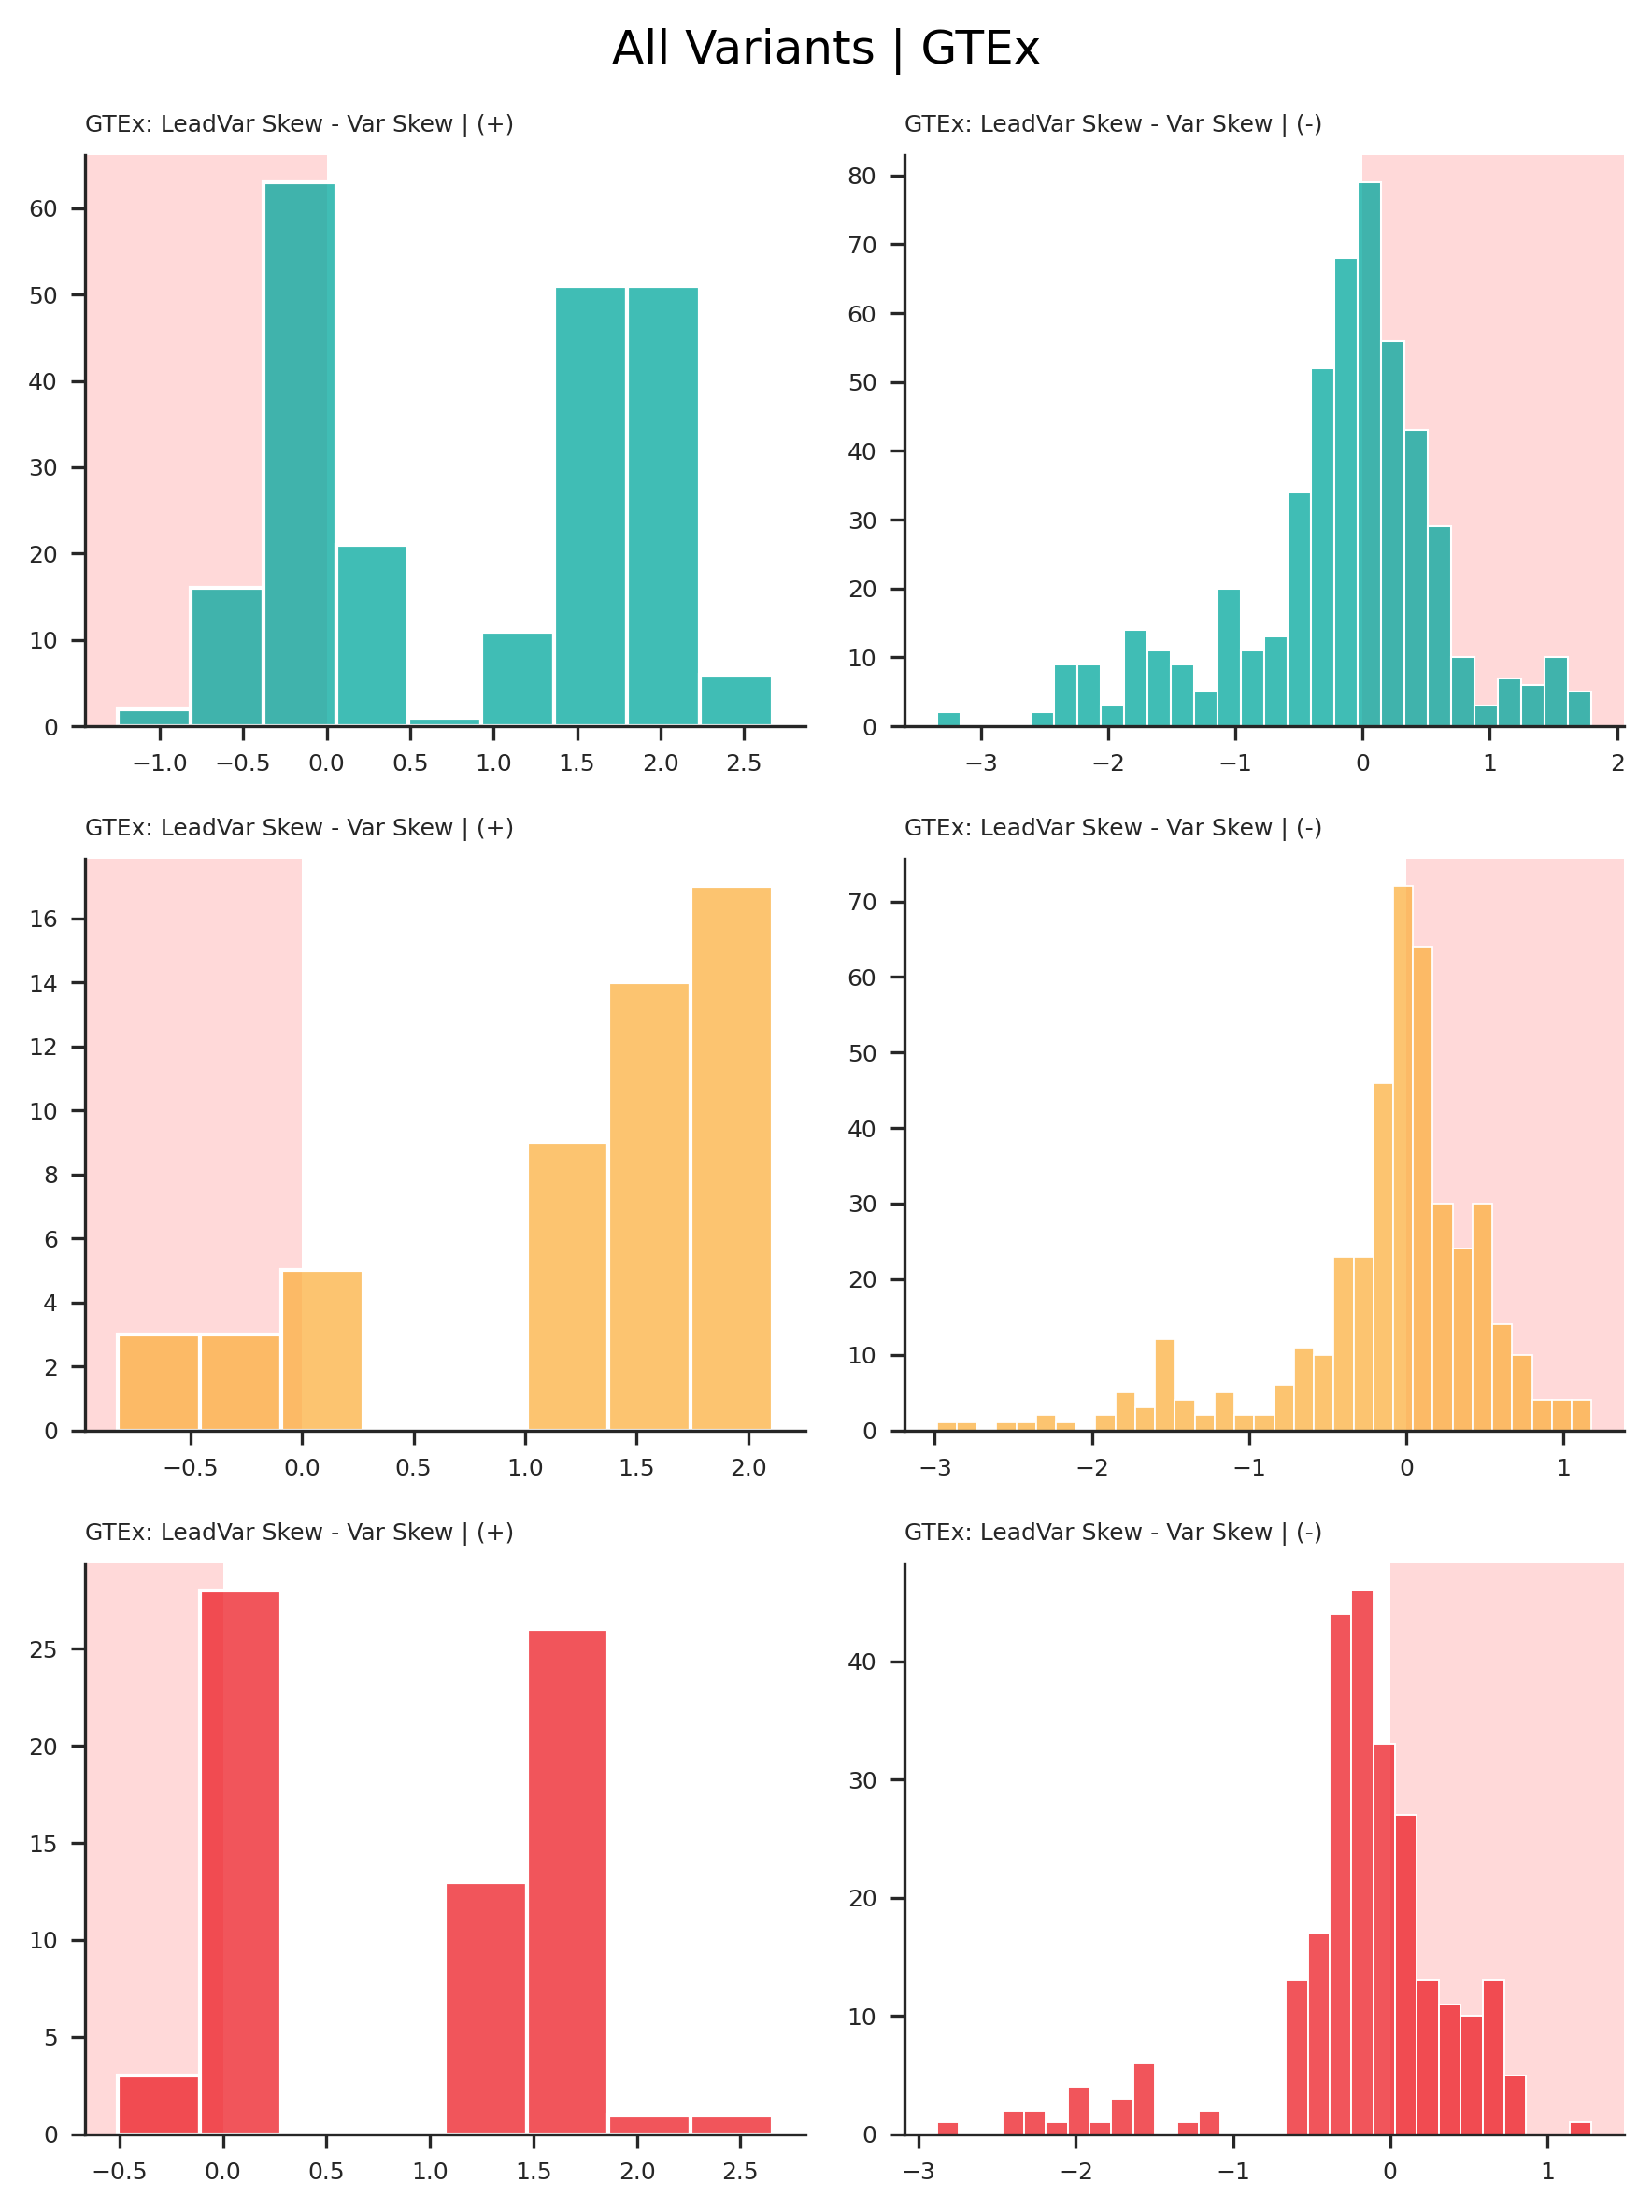

In [9]:
# split data into positive and negative skew and plot for each cell type
f = plt.figure(figsize = (6,8), dpi = 300)
gs = f.add_gridspec(3,2)
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['axes.labelsize'] = 8
# plot k562 positive lead skew #
with sns.axes_style('ticks'):
    kPosSkew = GTEx_multiTF[(GTEx_multiTF['leadVar_skew'] > 0) & (GTEx_multiTF['cell_type'] == 'k562')].filter(['delta_lead']).drop_duplicates()
    ax01 = f.add_subplot(gs[0,0])
    sns.histplot(
        data=kPosSkew,
        x='delta_lead',
        color='#00A79D'
    )
    # add shaded region for x < 0
    ymin, ymax = ax01.get_ylim()
    xmin, xmax = ax01.get_xlim()
    rect = patches.Rectangle(
        (xmin, ymin),              # bottom-left corner
        abs(xmin),                  # width (from xmin to 0)
        ymax - ymin,                # height (full y range)
        facecolor='red',
        alpha=0.15,
        edgecolor='none',
        zorder=0                    # behind the bars
    )
    ax01.add_patch(rect)
    ax01.tick_params(axis='both', labelsize=6)
    plt.title('GTEx: LeadVar Skew - Var Skew | (+)', loc = 'left', fontsize=6)
    plt.xlabel('')
    plt.ylabel('')
# plot k562 negative lead skew #
with sns.axes_style('ticks'):
    kNegSkew = GTEx_multiTF[(GTEx_multiTF['leadVar_skew'] <= 0) & (GTEx_multiTF['cell_type'] == 'k562')].filter(['delta_lead']).drop_duplicates()
    ax02 = f.add_subplot(gs[0,1])
    sns.histplot(
        data=kNegSkew,
        x='delta_lead',
        color='#00A79D'
    )
    # add shaded region for x < 0
    ymin, ymax = ax02.get_ylim()
    xmin, xmax = ax02.get_xlim()
    rect = patches.Rectangle(
        (0, ymin),              # bottom-left corner
        abs(xmax),                  # width (from xmin to 0)
        ymax - ymin,                # height (full y range)
        facecolor='red',
        alpha=0.15,
        edgecolor='none',
        zorder=0                    # behind the bars
    )
    ax02.add_patch(rect)
    ax02.tick_params(axis='both', labelsize=6)
    plt.title('GTEx: LeadVar Skew - Var Skew | (-)', loc = 'left', fontsize=6)
    plt.xlabel('')
    plt.ylabel('')
# plot hepg2 positive lead skew #
with sns.axes_style('ticks'):
    hPosSkew = GTEx_multiTF[(GTEx_multiTF['leadVar_skew'] > 0) & (GTEx_multiTF['cell_type'] == 'hepg2')].filter(['delta_lead']).drop_duplicates()
    ax03 = f.add_subplot(gs[1,0])
    sns.histplot(
        data=hPosSkew,
        x='delta_lead',
        color='#FBB040'
    )
    # add shaded region for x < 0
    ymin, ymax = ax03.get_ylim()
    xmin, xmax = ax03.get_xlim()
    rect = patches.Rectangle(
        (xmin, ymin),              # bottom-left corner
        abs(xmin),                  # width (from xmin to 0)
        ymax - ymin,                # height (full y range)
        facecolor='red',
        alpha=0.15,
        edgecolor='none',
        zorder=0                    # behind the bars
    )
    ax03.add_patch(rect)
    ax03.tick_params(axis='both', labelsize=6)
    plt.title('GTEx: LeadVar Skew - Var Skew | (+)', loc = 'left', fontsize=6)
    plt.xlabel('')
    plt.ylabel('')
# plot hepg2 negative lead skew #
with sns.axes_style('ticks'):
    hNegSkew = GTEx_multiTF[(GTEx_multiTF['leadVar_skew'] <= 0) & (GTEx_multiTF['cell_type'] == 'hepg2')].filter(['delta_lead']).drop_duplicates()
    ax04 = f.add_subplot(gs[1,1])
    sns.histplot(
        data=hNegSkew,
        x='delta_lead',
        color='#FBB040'
    )
    # add shaded region for x < 0
    ymin, ymax = ax04.get_ylim()
    xmin, xmax = ax04.get_xlim()
    rect = patches.Rectangle(
        (0, ymin),              # bottom-left corner
        abs(xmax),                  # width (from xmin to 0)
        ymax - ymin,                # height (full y range)
        facecolor='red',
        alpha=0.15,
        edgecolor='none',
        zorder=0                    # behind the bars
    )
    ax04.add_patch(rect)
    ax04.tick_params(axis='both', labelsize=6)
    plt.title('GTEx: LeadVar Skew - Var Skew | (-)', loc = 'left', fontsize=6)
    plt.xlabel('')
    plt.ylabel('')
# plot sknsh positive lead skew #
with sns.axes_style('ticks'):
    sPosSkew = GTEx_multiTF[(GTEx_multiTF['leadVar_skew'] > 0) & (GTEx_multiTF['cell_type'] == 'sknsh')].filter(['delta_lead']).drop_duplicates()
    ax05 = f.add_subplot(gs[2,0])
    sns.histplot(
        data=sPosSkew,
        x='delta_lead',
        color='#ED1C24'
    )
    # add shaded region for x < 0
    ymin, ymax = ax05.get_ylim()
    xmin, xmax = ax05.get_xlim()
    rect = patches.Rectangle(
        (xmin, ymin),              # bottom-left corner
        abs(xmin),                  # width (from xmin to 0)
        ymax - ymin,                # height (full y range)
        facecolor='red',
        alpha=0.15,
        edgecolor='none',
        zorder=0                    # behind the bars
    )
    ax05.add_patch(rect)
    ax05.tick_params(axis='both', labelsize=6)
    plt.title('GTEx: LeadVar Skew - Var Skew | (+)', loc = 'left', fontsize=6)
    plt.xlabel('')
    plt.ylabel('')
# plot sknsh negative lead skew #
with sns.axes_style('ticks'):
    sNegSkew = GTEx_multiTF[(GTEx_multiTF['leadVar_skew'] <= 0) & (GTEx_multiTF['cell_type'] == 'sknsh')].filter(['delta_lead']).drop_duplicates()
    ax06 = f.add_subplot(gs[2,1])
    sns.histplot(
        data=sNegSkew,
        x='delta_lead',
        color='#ED1C24'
    )
    # add shaded region for x < 0
    ymin, ymax = ax06.get_ylim()
    xmin, xmax = ax06.get_xlim()
    rect = patches.Rectangle(
        (0, ymin),              # bottom-left corner
        abs(xmax),                  # width (from xmin to 0)
        ymax - ymin,                # height (full y range)
        facecolor='red',
        alpha=0.15,
        edgecolor='none',
        zorder=0                    # behind the bars
    )
    ax06.add_patch(rect)
    ax06.tick_params(axis='both', labelsize=6)
    plt.title('GTEx: LeadVar Skew - Var Skew | (-)', loc = 'left', fontsize=6)
    plt.xlabel('')
    plt.ylabel('')
plt.suptitle('All Variants | GTEx')
sns.despine()
plt.tight_layout()

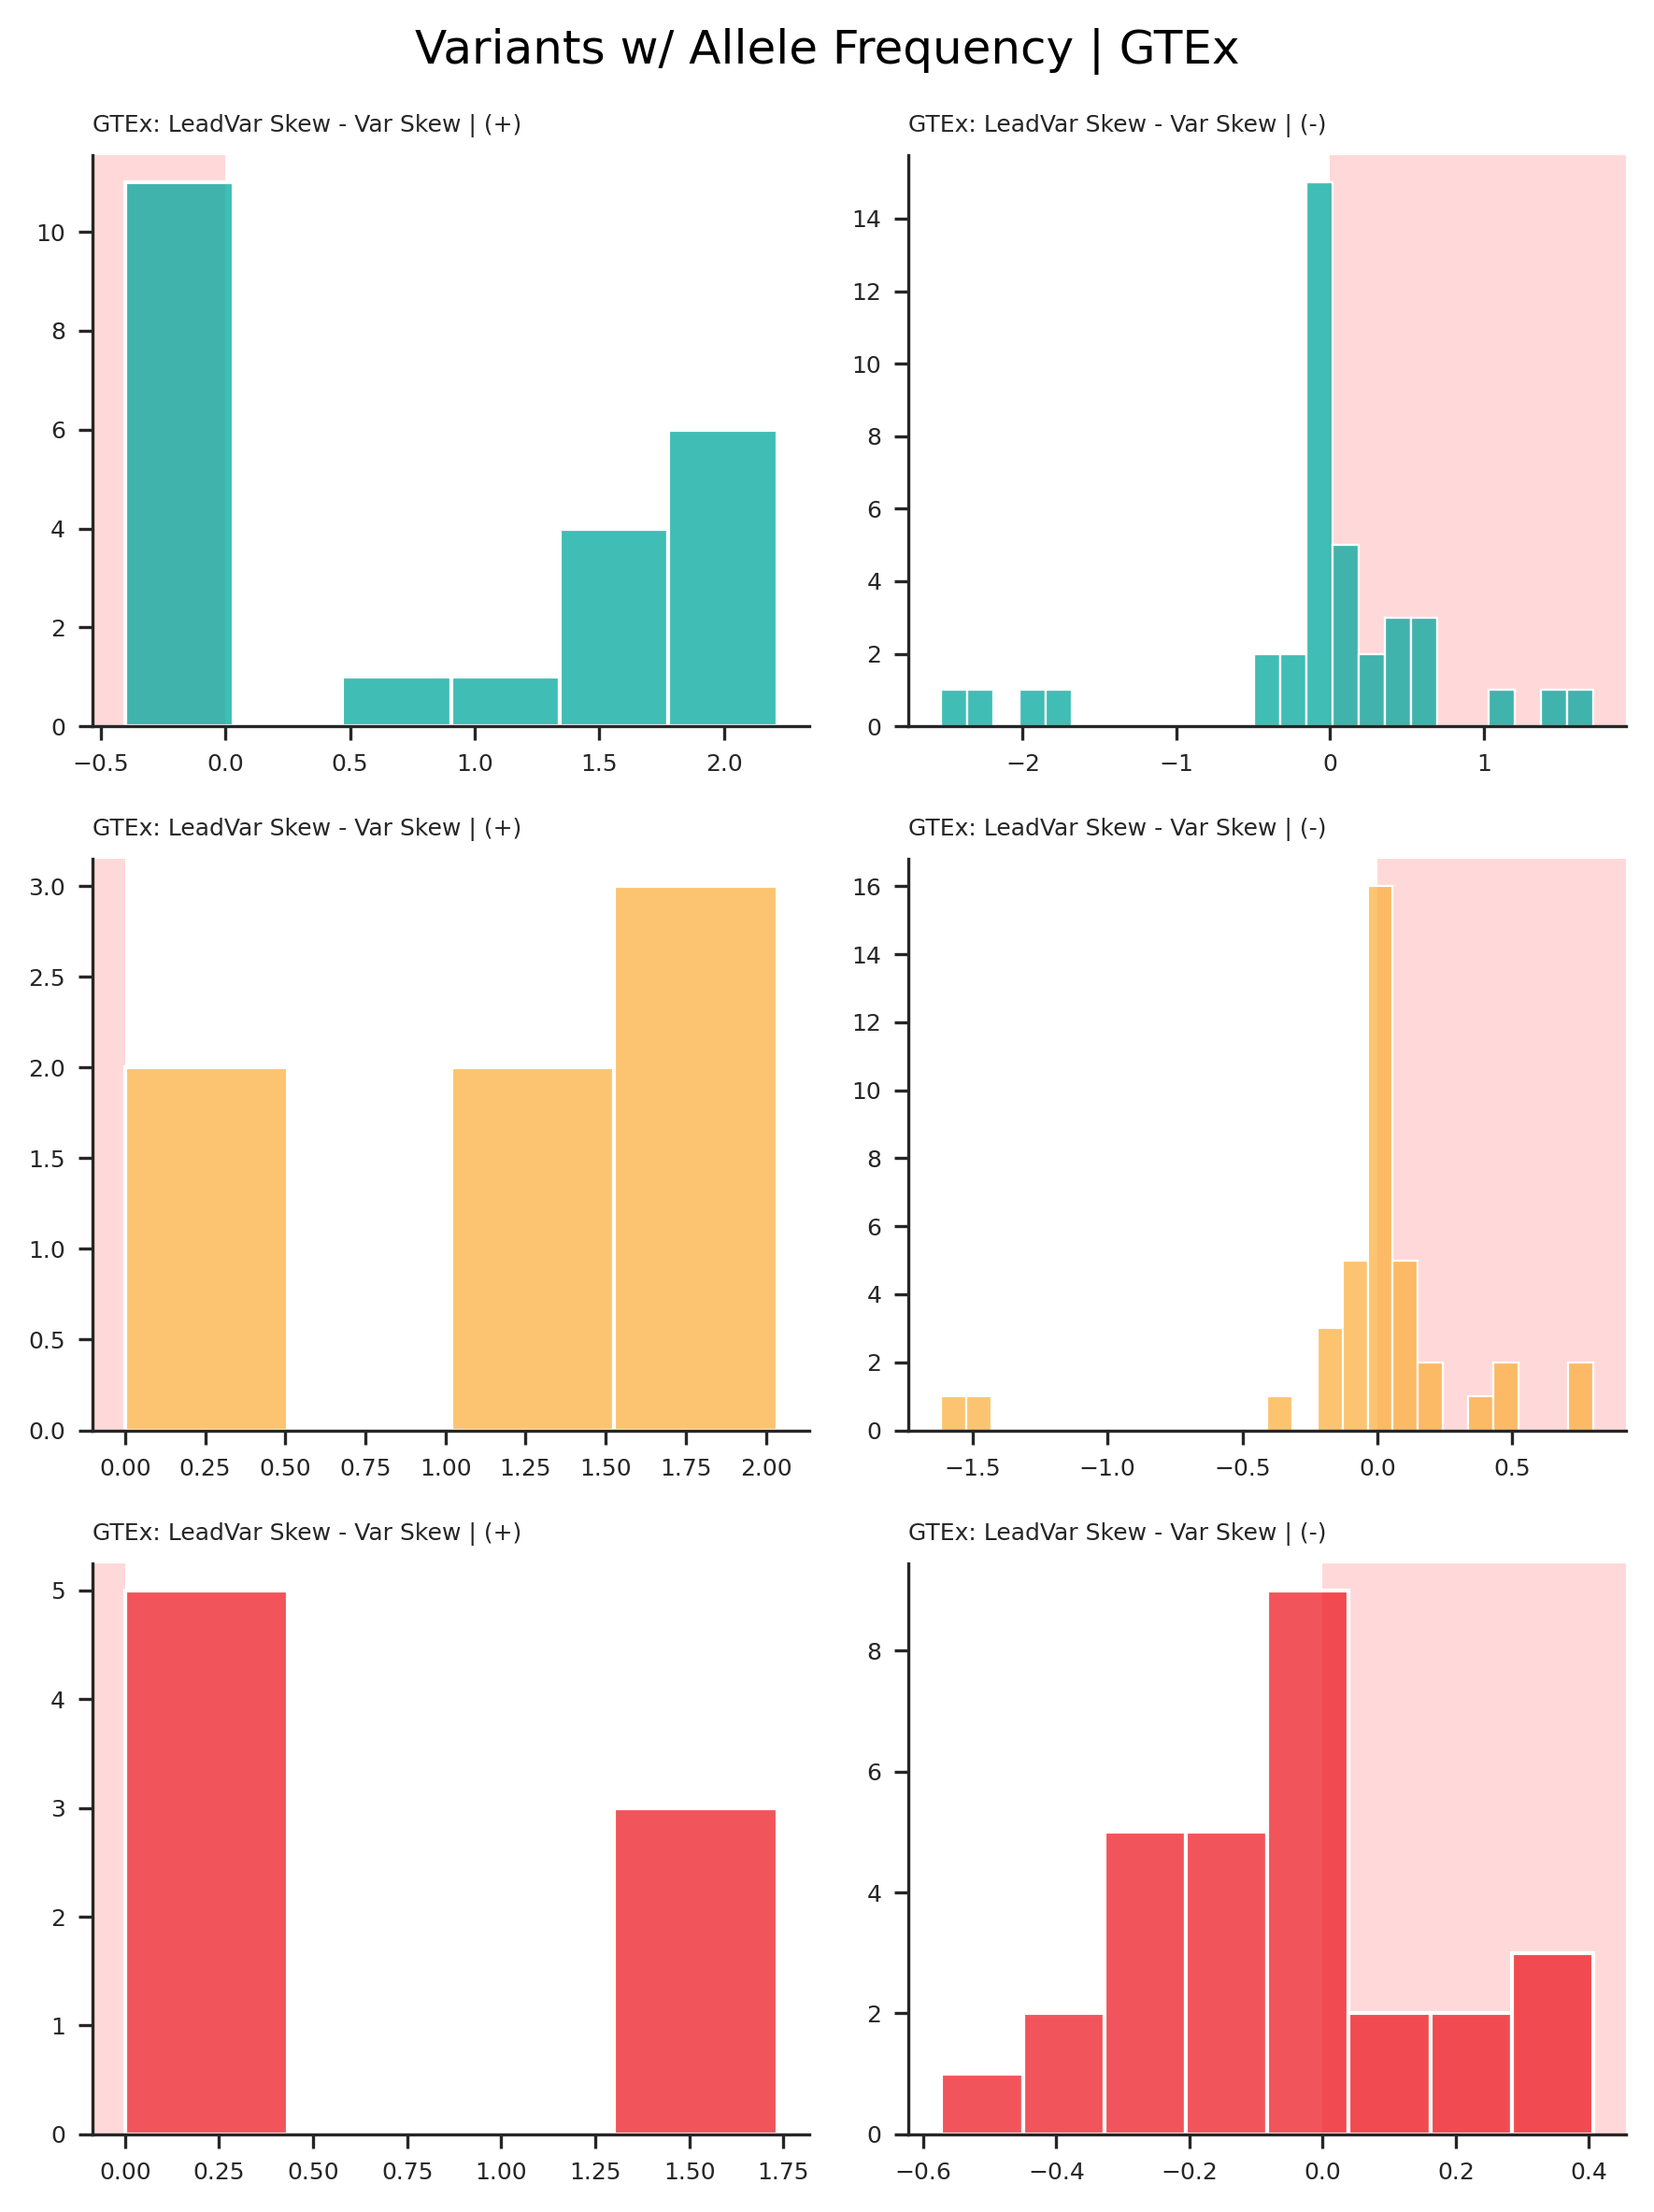

In [10]:
# split data into positive and negative skew and plot for each cell type
f = plt.figure(figsize = (6,8), dpi = 300)
gs = f.add_gridspec(3,2)
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['axes.labelsize'] = 8
# plot k562 positive lead skew #
with sns.axes_style('ticks'):
    kPosSkew = GTEx_multiTF[(GTEx_multiTF['leadVar_skew'] > 0) & (GTEx_multiTF['cell_type'] == 'k562')].filter(['delta_lead', 'af']).drop_duplicates().dropna()
    ax01 = f.add_subplot(gs[0,0])
    sns.histplot(
        data=kPosSkew,
        x='delta_lead',
        color='#00A79D'
    )
    # add shaded region for x < 0
    ymin, ymax = ax01.get_ylim()
    xmin, xmax = ax01.get_xlim()
    rect = patches.Rectangle(
        (xmin, ymin),              # bottom-left corner
        abs(xmin),                  # width (from xmin to 0)
        ymax - ymin,                # height (full y range)
        facecolor='red',
        alpha=0.15,
        edgecolor='none',
        zorder=0                    # behind the bars
    )
    ax01.add_patch(rect)
    ax01.tick_params(axis='both', labelsize=6)
    plt.title('GTEx: LeadVar Skew - Var Skew | (+)', loc = 'left', fontsize=6)
    plt.xlabel('')
    plt.ylabel('')
# plot k562 negative lead skew #
with sns.axes_style('ticks'):
    kNegSkew = GTEx_multiTF[(GTEx_multiTF['leadVar_skew'] <= 0) & (GTEx_multiTF['cell_type'] == 'k562')].filter(['delta_lead', 'af']).drop_duplicates().dropna()
    ax02 = f.add_subplot(gs[0,1])
    sns.histplot(
        data=kNegSkew,
        x='delta_lead',
        color='#00A79D'
    )
    # add shaded region for x < 0
    ymin, ymax = ax02.get_ylim()
    xmin, xmax = ax02.get_xlim()
    rect = patches.Rectangle(
        (0, ymin),              # bottom-left corner
        abs(xmax),                  # width (from xmin to 0)
        ymax - ymin,                # height (full y range)
        facecolor='red',
        alpha=0.15,
        edgecolor='none',
        zorder=0                    # behind the bars
    )
    ax02.add_patch(rect)
    ax02.tick_params(axis='both', labelsize=6)
    plt.title('GTEx: LeadVar Skew - Var Skew | (-)', loc = 'left', fontsize=6)
    plt.xlabel('')
    plt.ylabel('')
# plot hepg2 positive lead skew #
with sns.axes_style('ticks'):
    hPosSkew = GTEx_multiTF[(GTEx_multiTF['leadVar_skew'] > 0) & (GTEx_multiTF['cell_type'] == 'hepg2')].filter(['delta_lead', 'af']).drop_duplicates().dropna()
    ax03 = f.add_subplot(gs[1,0])
    sns.histplot(
        data=hPosSkew,
        x='delta_lead',
        color='#FBB040'
    )
    # add shaded region for x < 0
    ymin, ymax = ax03.get_ylim()
    xmin, xmax = ax03.get_xlim()
    rect = patches.Rectangle(
        (xmin, ymin),              # bottom-left corner
        abs(xmin),                  # width (from xmin to 0)
        ymax - ymin,                # height (full y range)
        facecolor='red',
        alpha=0.15,
        edgecolor='none',
        zorder=0                    # behind the bars
    )
    ax03.add_patch(rect)
    ax03.tick_params(axis='both', labelsize=6)
    plt.title('GTEx: LeadVar Skew - Var Skew | (+)', loc = 'left', fontsize=6)
    plt.xlabel('')
    plt.ylabel('')
# plot hepg2 negative lead skew #
with sns.axes_style('ticks'):
    hNegSkew = GTEx_multiTF[(GTEx_multiTF['leadVar_skew'] <= 0) & (GTEx_multiTF['cell_type'] == 'hepg2')].filter(['delta_lead', 'af']).drop_duplicates().dropna()
    ax04 = f.add_subplot(gs[1,1])
    sns.histplot(
        data=hNegSkew,
        x='delta_lead',
        color='#FBB040'
    )
    # add shaded region for x < 0
    ymin, ymax = ax04.get_ylim()
    xmin, xmax = ax04.get_xlim()
    rect = patches.Rectangle(
        (0, ymin),              # bottom-left corner
        abs(xmax),                  # width (from xmin to 0)
        ymax - ymin,                # height (full y range)
        facecolor='red',
        alpha=0.15,
        edgecolor='none',
        zorder=0                    # behind the bars
    )
    ax04.add_patch(rect)
    ax04.tick_params(axis='both', labelsize=6)
    plt.title('GTEx: LeadVar Skew - Var Skew | (-)', loc = 'left', fontsize=6)
    plt.xlabel('')
    plt.ylabel('')
# plot sknsh positive lead skew #
with sns.axes_style('ticks'):
    sPosSkew = GTEx_multiTF[(GTEx_multiTF['leadVar_skew'] > 0) & (GTEx_multiTF['cell_type'] == 'sknsh')].filter(['delta_lead', 'af']).drop_duplicates().dropna()
    ax05 = f.add_subplot(gs[2,0])
    sns.histplot(
        data=sPosSkew,
        x='delta_lead',
        color='#ED1C24'
    )
    # add shaded region for x < 0
    ymin, ymax = ax05.get_ylim()
    xmin, xmax = ax05.get_xlim()
    rect = patches.Rectangle(
        (xmin, ymin),              # bottom-left corner
        abs(xmin),                  # width (from xmin to 0)
        ymax - ymin,                # height (full y range)
        facecolor='red',
        alpha=0.15,
        edgecolor='none',
        zorder=0                    # behind the bars
    )
    ax05.add_patch(rect)
    ax05.tick_params(axis='both', labelsize=6)
    plt.title('GTEx: LeadVar Skew - Var Skew | (+)', loc = 'left', fontsize=6)
    plt.xlabel('')
    plt.ylabel('')
# plot sknsh negative lead skew #
with sns.axes_style('ticks'):
    sNegSkew = GTEx_multiTF[(GTEx_multiTF['leadVar_skew'] <= 0) & (GTEx_multiTF['cell_type'] == 'sknsh')].filter(['delta_lead', 'af']).drop_duplicates().dropna()
    ax06 = f.add_subplot(gs[2,1])
    sns.histplot(
        data=sNegSkew,
        x='delta_lead',
        color='#ED1C24'
    )
    # add shaded region for x < 0
    ymin, ymax = ax06.get_ylim()
    xmin, xmax = ax06.get_xlim()
    rect = patches.Rectangle(
        (0, ymin),              # bottom-left corner
        abs(xmax),                  # width (from xmin to 0)
        ymax - ymin,                # height (full y range)
        facecolor='red',
        alpha=0.15,
        edgecolor='none',
        zorder=0                    # behind the bars
    )
    ax06.add_patch(rect)
    ax06.tick_params(axis='both', labelsize=6)
    plt.title('GTEx: LeadVar Skew - Var Skew | (-)', loc = 'left', fontsize=6)
    plt.xlabel('')
    plt.ylabel('')
plt.suptitle('Variants w/ Allele Frequency | GTEx')
sns.despine()
plt.tight_layout()

In [22]:
GTEx_multiTF[(GTEx_multiTF['leadVar_skew'] <= 0) & # get negative skews
             (GTEx_multiTF['cell_type'] == 'k562') & # get cell type
             (GTEx_multiTF['delta_lead'] >0.5)].drop_duplicates().dropna() # get the large effect instances and frop those without allele frequencies

,variant_id,chrom,pos,ref,alt,cell_type,skew_pred,enhancer_ids,is_multiTF,gtex_id,tf_family,tf_contrib,tf_instance,leadVar,is_leadVariant,af,gtex_id_eqtl,phenotype_id,gene_name,biotype,tissue,pip,af_eqtl,afc,afc_se,cs_id,cs_size,abs_skew,lead_abs_skew,max_abs_skew,skew_ratio,leadVar_skew,delta_lead
3812,chr7:65731820:G:C,chr7,65731820,G,C,k562,-1.970768,EH38E3776679,True,chr7_65731820_G_C_b38,KLF/SP/2,14.640605,1,chr7_65731813_T_C_b38,0,0.000007,chr7_65731813_T_C_b38,ENSG00000236529.2,ENSG00000236529,lncRNA,Cells_Cultured_fibroblasts,0.997727,0.839754,-0.745597,0.103113,2,1,1.970768,0.528722,2.327588,4.402293,-0.528722,1.442047
3819,chr7:65731822:C:T,chr7,65731822,C,T,k562,-2.242539,EH38E3776679,True,chr7_65731822_C_T_b38,KLF/SP/2,14.640605,1,chr7_65731813_T_C_b38,0,0.000007,chr7_65731813_T_C_b38,ENSG00000236529.2,ENSG00000236529,lncRNA,Cells_Cultured_fibroblasts,0.997727,0.839754,-0.745597,0.103113,2,1,2.242539,0.528722,2.327588,4.402293,-0.528722,1.713817
3993,chr9:114552154:T:G,chr9,114552154,T,G,k562,-2.190342,EH38E3903446,True,chr9_114552154_T_G_b38,AP1/1,15.043160,3,chr9_114552099_G_A_b38,0,0.000033,chr9_114552099_G_A_b38,ENSG00000095397.16,WHRN,protein_coding,Cells_Cultured_fibroblasts,0.999993,0.346687,-1.485546,0.103312,1,1,2.190342,1.038335,2.499703,2.407413,-1.038335,1.152007
4349,chr6:6682484:G:A,chr6,6682484,G,A,k562,-1.388678,EH38E3688576,True,chr6_6682484_G_A_b38,ETS/2,6.402445,3,chr6_6682429_A_C_b38,0,0.000013,chr6_6682429_A_C_b38,ENSG00000216863.10,LY86-AS1,lncRNA,Whole_Blood,0.954106,0.500000,-0.556648,0.092211,1,1,1.388678,0.800041,1.841645,2.301939,-0.800041,0.588637
4350,chr6:6682484:G:A,chr6,6682484,G,A,k562,-1.388678,EH38E3688576,True,chr6_6682484_G_A_b38,ETS/2,6.402445,3,chr6_6682429_A_C_b38,0,0.000013,chr6_6682429_A_C_b38,ENSG00000261211.2,ENSG00000261211,lncRNA,Whole_Blood,0.996896,0.500000,-1.255423,0.104885,1,1,1.388678,0.800041,1.841645,2.301939,-0.800041,0.588637
5001,chr20:3753833:C:T,chr20,3753833,C,T,k562,-1.131608,EH38E3417196,True,chr20_3753833_C_T_b38,ETS/1,6.189360,1,chr20_3753867_T_C_b38,0,0.000059,chr20_3753867_T_C_b38,ENSG00000101220.18,C20orf27,protein_coding,Lung,0.996098,0.348586,-0.257179,0.070329,2,1,1.131608,0.500018,2.029712,4.059276,-0.500018,0.631590
5002,chr20:3753834:G:A,chr20,3753834,G,A,k562,-1.076284,EH38E3417196,True,chr20_3753834_G_A_b38,ETS/1,6.189360,1,chr20_3753867_T_C_b38,0,0.000059,chr20_3753867_T_C_b38,ENSG00000101220.18,C20orf27,protein_coding,Lung,0.996098,0.348586,-0.257179,0.070329,2,1,1.076284,0.500018,2.029712,4.059276,-0.500018,0.576266


In [25]:
GTEx_multiTF[(GTEx_multiTF['leadVar_skew'] <= 0) & # get negative skews
             (GTEx_multiTF['cell_type'] == 'hepg2') & # get cell type
             (GTEx_multiTF['delta_lead'] > 0.5)].drop_duplicates().dropna() # get the large effect instances and frop those without allele frequencies

,variant_id,chrom,pos,ref,alt,cell_type,skew_pred,enhancer_ids,is_multiTF,gtex_id,tf_family,tf_contrib,tf_instance,leadVar,is_leadVariant,af,gtex_id_eqtl,phenotype_id,gene_name,biotype,tissue,pip,af_eqtl,afc,afc_se,cs_id,cs_size,abs_skew,lead_abs_skew,max_abs_skew,skew_ratio,leadVar_skew,delta_lead
3781,chr18:34153910:G:A,chr18,34153910,G,A,hepg2,-1.311947,EH38E1908595,True,chr18_34153910_G_A_b38,ETS/2,8.961218,2,chr18_34153887_G_C_b38,0,0.000007,chr18_34153887_G_C_b38,ENSG00000141431.13,ASXL3,protein_coding,Vagina,0.938454,0.011765,-1.664438,1.072828,1,2,1.311947,0.510436,1.690453,3.311785,-0.510436,0.801511
4435,chr6:6682484:G:A,chr6,6682484,G,A,hepg2,-1.287338,EH38E3688576,True,chr6_6682484_G_A_b38,ETS/2,7.448113,2,chr6_6682429_A_C_b38,0,0.000013,chr6_6682429_A_C_b38,ENSG00000216863.10,LY86-AS1,lncRNA,Whole_Blood,0.954106,0.500000,-0.556648,0.092211,1,1,1.287338,0.524514,1.499674,2.859170,-0.524514,0.762824
4436,chr6:6682484:G:A,chr6,6682484,G,A,hepg2,-1.287338,EH38E3688576,True,chr6_6682484_G_A_b38,ETS/2,7.448113,2,chr6_6682429_A_C_b38,0,0.000013,chr6_6682429_A_C_b38,ENSG00000261211.2,ENSG00000261211,lncRNA,Whole_Blood,0.996896,0.500000,-1.255423,0.104885,1,1,1.287338,0.524514,1.499674,2.859170,-0.524514,0.762824


In [28]:
GTEx_multiTF[(GTEx_multiTF['leadVar_skew'] <= 0) & # get negative skews
             (GTEx_multiTF['cell_type'] == 'sknsh') & # get cell type
             (GTEx_multiTF['delta_lead'] > 0.25)].drop_duplicates().dropna().sort_values(by=['leadVar', 'phenotype_id']) # get the large effect instances and frop those without allele frequencies

,variant_id,chrom,pos,ref,alt,cell_type,skew_pred,enhancer_ids,is_multiTF,gtex_id,tf_family,tf_contrib,tf_instance,leadVar,is_leadVariant,af,gtex_id_eqtl,phenotype_id,gene_name,biotype,tissue,pip,af_eqtl,afc,afc_se,cs_id,cs_size,abs_skew,lead_abs_skew,max_abs_skew,skew_ratio,leadVar_skew,delta_lead
4618,chr19:15900206:A:G,chr19,15900206,A,G,sknsh,-1.514493,EH38E1942166,True,chr19_15900206_A_G_b38,NFY,11.084738,1,chr19_15900209_A_T_b38,0,0.000033,chr19_15900209_A_T_b38,ENSG00000186115.13,CYP4F2,protein_coding,Stomach,0.994755,0.015971,1.608650,0.660050,1,1,1.514493,1.132576,1.938768,1.711821,-1.132576,0.381916
4619,chr19:15900206:A:G,chr19,15900206,A,G,sknsh,-1.514493,EH38E1942166,True,chr19_15900206_A_G_b38,NFY,11.084738,1,chr19_15900209_A_T_b38,0,0.000033,chr19_15900209_A_T_b38,ENSG00000186115.13,CYP4F2,protein_coding,Pancreas,1.000000,0.023481,7.635592,0.568821,1,1,1.514493,1.132576,1.938768,1.711821,-1.132576,0.381916
4678,chr19:15900244:A:G,chr19,15900244,A,G,sknsh,-1.409701,EH38E1942166,True,chr19_15900244_A_G_b38,NFY,11.587471,2,chr19_15900209_A_T_b38,0,0.000007,chr19_15900209_A_T_b38,ENSG00000186115.13,CYP4F2,protein_coding,Stomach,0.994755,0.015971,1.608650,0.660050,1,1,1.409701,1.132576,1.938768,1.711821,-1.132576,0.277124
4679,chr19:15900244:A:G,chr19,15900244,A,G,sknsh,-1.409701,EH38E1942166,True,chr19_15900244_A_G_b38,NFY,11.587471,2,chr19_15900209_A_T_b38,0,0.000007,chr19_15900209_A_T_b38,ENSG00000186115.13,CYP4F2,protein_coding,Pancreas,1.000000,0.023481,7.635592,0.568821,1,1,1.409701,1.132576,1.938768,1.711821,-1.132576,0.277124
4020,chr9:114552098:C:G,chr9,114552098,C,G,sknsh,-1.223021,EH38E3903446,True,chr9_114552098_C_G_b38,AP1/1,5.012476,1,chr9_114552099_G_A_b38,0,0.000007,chr9_114552099_G_A_b38,ENSG00000095397.16,WHRN,protein_coding,Cells_Cultured_fibroblasts,0.999993,0.346687,-1.485546,0.103312,1,1,1.223021,0.879080,1.591081,1.809939,-0.879080,0.343941
4039,chr9:114552154:T:G,chr9,114552154,T,G,sknsh,-1.285684,EH38E3903446,True,chr9_114552154_T_G_b38,AP1/1,7.360513,2,chr9_114552099_G_A_b38,0,0.000033,chr9_114552099_G_A_b38,ENSG00000095397.16,WHRN,protein_coding,Cells_Cultured_fibroblasts,0.999993,0.346687,-1.485546,0.103312,1,1,1.285684,0.879080,1.591081,1.809939,-0.879080,0.406604
